# Ames Housing: Exploratory Data Analysis

Part 2 of the Ames Housing project. Continues from `01_cleaning.ipynb`, which resolves all missing values in the raw dataset and produces `train_cleaned.csv`.

This notebook covers univariate, bivariate, and multivariate analysis. The goal is to test assumptions rather than accept surface-level patterns, applying the same rigor used in an earlier Titanic EDA project from the start, instead of discovering it partway through.

**Initial hypothesis, before looking at the data:** land area, location, and room count are likely the strongest predictors of `SalePrice`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train_cleaned.csv", keep_default_na=False, na_values=[])
df["MSSubClass"] = df["MSSubClass"].astype(str)

numeric_cols = df.select_dtypes(include="number").columns.tolist()
object_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


## SalePrice

Starting with the target variable. Prediction: right-skewed, similar to `Fare` in the Titanic dataset, since most price data clusters around a typical value with a thinning tail of expensive homes.

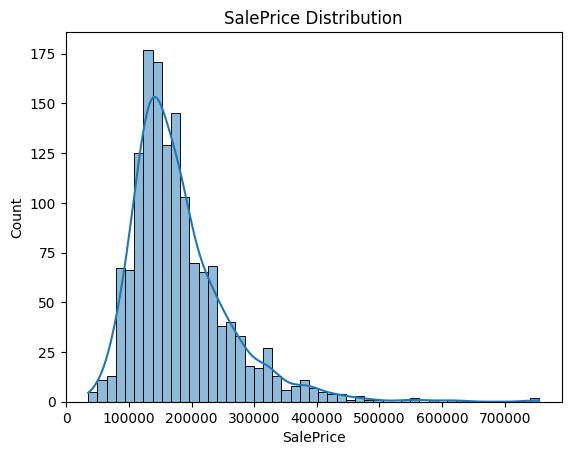

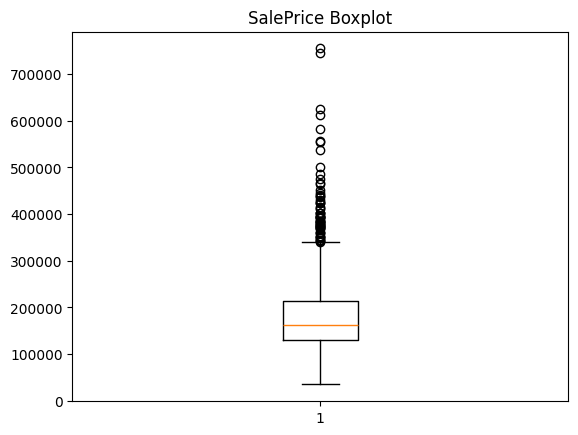

np.float64(1.8828757597682129)

In [2]:
sns.histplot(data=df, x="SalePrice", kde=True)
plt.title("SalePrice Distribution")
plt.show()

plt.boxplot(df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.show()

df["SalePrice"].skew()

**Finding:** confirmed. Skew of 1.8, well past the threshold for strong skew. Mean (\$180,921) sits about \$18,000 above the median (\$163,000), typical of right-skewed data where a small number of high-value homes pull the mean up without moving the median as much. Median is the more representative measure of a typical home here.

In [3]:
def find_outliers(df, col):
    """Return rows outside 1.5x IQR for a given column, sorted descending."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)].sort_values(col, ascending=False)
    print(f"Bounds: {lower:.0f} to {upper:.0f}. Outliers: {len(outliers)}")
    return outliers

In [4]:
outliers = find_outliers(df, "SalePrice")
cols_of_interest = ["SalePrice", "OverallQual", "BedroomAbvGr", "Neighborhood", "GrLivArea", "LotArea", "ExterCond", "ExterQual"]
df.loc[outliers.index, cols_of_interest].head(10)

Bounds: 3938 to 340038. Outliers: 61


,SalePrice,OverallQual,BedroomAbvGr,Neighborhood,GrLivArea,LotArea,ExterCond,ExterQual
691,755000,10,4,NoRidge,4316,21535,TA,Ex
1182,745000,10,4,NoRidge,4476,15623,TA,Gd
1169,625000,10,4,NoRidge,3627,35760,Gd,Gd
898,611657,9,2,NridgHt,2364,12919,TA,Ex
803,582933,9,4,NridgHt,2822,13891,TA,Ex
1046,556581,9,4,StoneBr,2868,16056,TA,Gd
440,555000,10,2,NridgHt,2402,15431,TA,Ex
769,538000,8,4,StoneBr,3279,53504,TA,Ex
178,501837,9,1,StoneBr,2234,17423,TA,Ex
798,485000,9,4,NridgHt,3140,13518,TA,Ex


**Finding:** 61 outliers, all above the upper bound. None below it: the lower bound (~\$3,937) is far below any realistic price, so no house could ever fall under it.

**Observations from the outlier rows (not yet tested, real correlation checks come in bivariate):**
- `OverallQual` appears high and consistent across these houses.
- Outliers are concentrated in `NoRidge` and `NridgHt`.
- `GrLivArea` also appears elevated.
- `LotArea` does not look like a consistent proxy for price here, a reversal of the original hypothesis.
- `ExterCond` and `ExterQual` are mostly TA and above.

This is only a look at houses already selected for being expensive, so it cannot yet prove these features drive price in general. The real test is a full-dataset correlation check.

## Fast Scan

A lightweight pass across every column before deciding what deserves full treatment. Flags anything with high skew, an unusual range, or a categorical column dominated by one value.

In [5]:
df[numeric_cols].describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,70.199658,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.398630,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,46.228767,6.321918,2007.815753,180921.195890
std,421.610009,22.431902,9981.264932,1.382997,1.112799,30.202904,20.645407,180.730605,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,504.439884,2.703626,1.328095,79442.502883
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
for col in object_cols:
    top_value, top_share = df[col].value_counts(normalize=True).head(1).items().__next__()
    print(f"{col}: {top_value} ({top_share:.1%})")

MSSubClass: 20 (36.7%)
MSZoning: RL (78.8%)
Street: Pave (99.6%)
Alley: None (93.8%)
LotShape: Reg (63.4%)
LandContour: Lvl (89.8%)
Utilities: AllPub (99.9%)
LotConfig: Inside (72.1%)
LandSlope: Gtl (94.7%)
Neighborhood: NAmes (15.4%)
Condition1: Norm (86.3%)
Condition2: Norm (99.0%)
BldgType: 1Fam (83.6%)
HouseStyle: 1Story (49.7%)
RoofStyle: Gable (78.2%)
RoofMatl: CompShg (98.2%)
Exterior1st: VinylSd (35.3%)
Exterior2nd: VinylSd (34.5%)
MasVnrType: None (59.4%)
ExterQual: TA (62.1%)
ExterCond: TA (87.8%)
Foundation: PConc (44.3%)
BsmtQual: TA (44.5%)
BsmtCond: TA (89.8%)
BsmtExposure: No (65.3%)
BsmtFinType1: Unf (29.5%)
BsmtFinType2: Unf (86.1%)
Heating: GasA (97.8%)
HeatingQC: Ex (50.8%)
CentralAir: Y (93.5%)
Electrical: SBrkr (91.4%)
KitchenQual: TA (50.3%)
Functional: Typ (93.2%)
FireplaceQu: None (47.3%)
GarageType: Attchd (59.6%)
GarageFinish: Unf (41.4%)
GarageQual: TA (89.8%)
GarageCond: TA (90.8%)
PavedDrive: Y (91.8%)
PoolQC: None (99.5%)
Fence: None (80.8%)
MiscFeature: N

`Street` stands out: `Pave` accounts for 99.6% of rows, only 6 houses have `Grvl`. This is a low-variance column and a candidate to drop later during feature selection.

`MoSold` also stands out: stored as a number but conceptually categorical, since months have no ranking, though they do have a cyclical relationship (December sits close to January).

## MoSold

Checking for a pattern before deciding how to treat it.

In [7]:
df.groupby("MoSold")["SalePrice"].agg(["mean", "count"]).sort_values("count", ascending=False)

,mean,count
MoSold,,
6,177395.735178,253
7,186331.192308,234
5,172307.269608,204
4,171503.262411,141
8,184651.827869,122
3,183253.924528,106
10,179563.977528,89
11,192210.911392,79
9,195683.206349,63


**Finding:** May to July show the highest sales volume, consistent with the typical US spring and summer moving season. September shows the highest average price, April the lowest. Flagged for a proper test in bivariate analysis.

## OverallQual

One of the strongest candidates from the outlier review. Prediction: right-skewed, like `SalePrice`.

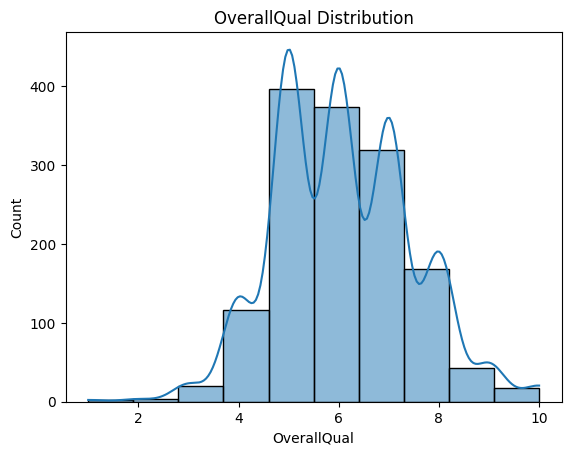

np.float64(0.2169439277628693)

In [8]:
sns.histplot(data=df, x="OverallQual", kde=True, bins=10)
plt.title("OverallQual Distribution")
plt.show()

df["OverallQual"].skew()

**Finding:** skew of 0.22, close to zero. The prediction was wrong. Unlike `SalePrice`, `OverallQual` has a fixed minimum and maximum (a 1 to 10 rating scale), which limits how extreme outliers can get. The histogram peaks around 5, consistent with mean and median sitting close together at near-zero skew.

**Observation:** more low outliers than high ones by eye. Hypothesis, untested: `OverallQual` may act as a rough proxy for status, and most buyers cluster around average to slightly-above-average, which is typical of a middle-market population.

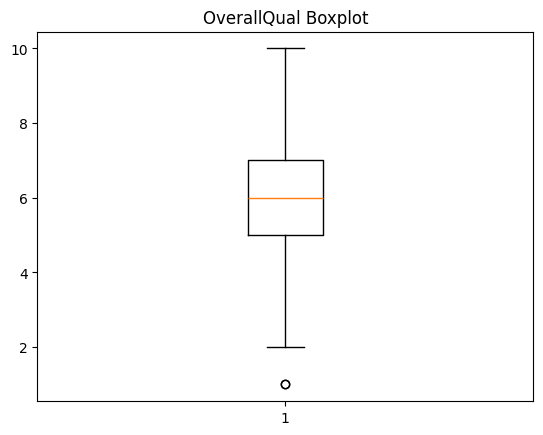

Bounds: 2 to 10. Outliers: 2


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
375,376,30,RL,65.5,10020,Pave,None,IR1,Low,AllPub,...,0,None,None,None,0,3,2009,WD,Normal,61000
533,534,20,RL,50.0,5000,Pave,None,Reg,Low,AllPub,...,0,None,None,None,0,1,2007,WD,Normal,39300


In [9]:
plt.boxplot(df["OverallQual"])
plt.title("OverallQual Boxplot")
plt.show()

find_outliers(df, "OverallQual")

**Finding:** only 2 outliers, both rated 1, the lowest possible score. This is the mirror opposite of `SalePrice`: there, all outliers were high. Here, they are low. Genuinely poor-quality houses are rare enough in this dataset to stand out statistically, while excellent ones are common enough not to.

## GrLivArea

Above-ground living area, the second core column from the original hypothesis. Prediction: right-skewed, same as other raw area measurements checked this week.

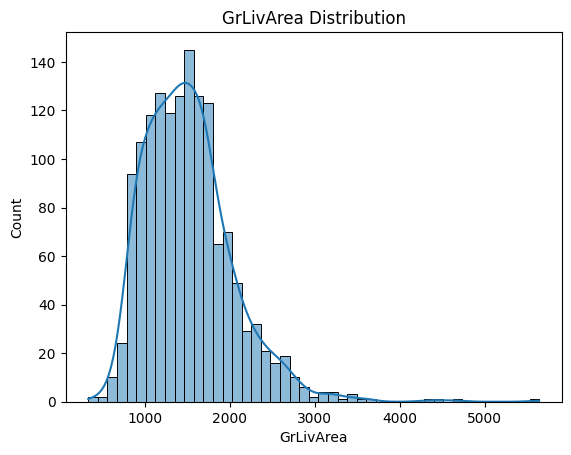

np.float64(1.3665603560164552)

In [10]:
sns.histplot(data=df, x="GrLivArea", kde=True)
plt.title("GrLivArea Distribution")
plt.show()

df["GrLivArea"].skew()

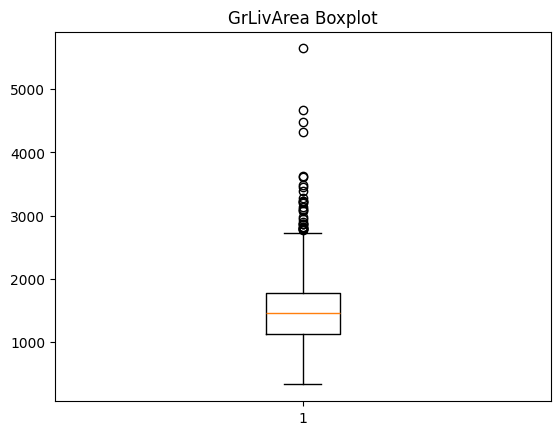

Bounds: 159 to 2748. Outliers: 31


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,...,480,Gd,None,None,0,1,2008,New,Partial,160000
523,524,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,...,0,None,None,None,0,10,2007,New,Partial,184750
1182,1183,60,RL,160.0,15623,Pave,None,IR1,Lvl,AllPub,...,555,Ex,MnPrv,None,0,7,2007,WD,Abnorml,745000
691,692,60,RL,104.0,21535,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,1,2007,WD,Normal,755000
1169,1170,60,RL,118.0,35760,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,7,2006,WD,Normal,625000
185,186,75,RM,90.0,22950,Pave,None,IR2,Lvl,AllPub,...,0,None,GdPrv,None,0,6,2006,WD,Normal,475000
304,305,75,RM,87.0,18386,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2008,WD,Normal,295000
1268,1269,50,RL,74.0,14100,Pave,None,IR1,Lvl,AllPub,...,0,None,GdWo,None,0,5,2008,WD,Normal,381000
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,None,None,None,0,3,2007,WD,Abnorml,200000
769,770,60,RL,47.0,53504,Pave,None,IR2,HLS,AllPub,...,0,None,None,None,0,6,2010,WD,Normal,538000


In [11]:
plt.boxplot(df["GrLivArea"])
plt.title("GrLivArea Boxplot")
plt.show()

find_outliers(df, "GrLivArea")

**Finding:** skew of 1.3, confirmed right-skewed. All outliers fall above the upper bound, none below, matching the same pattern as `SalePrice`. For open-ended measurements like size and price, large tends to be the rare case, not small.

## Neighborhood

The third core column from the original hypothesis, and already flagged as relevant: `NoRidge` and `NridgHt` were overrepresented among price outliers.

In [12]:
df["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

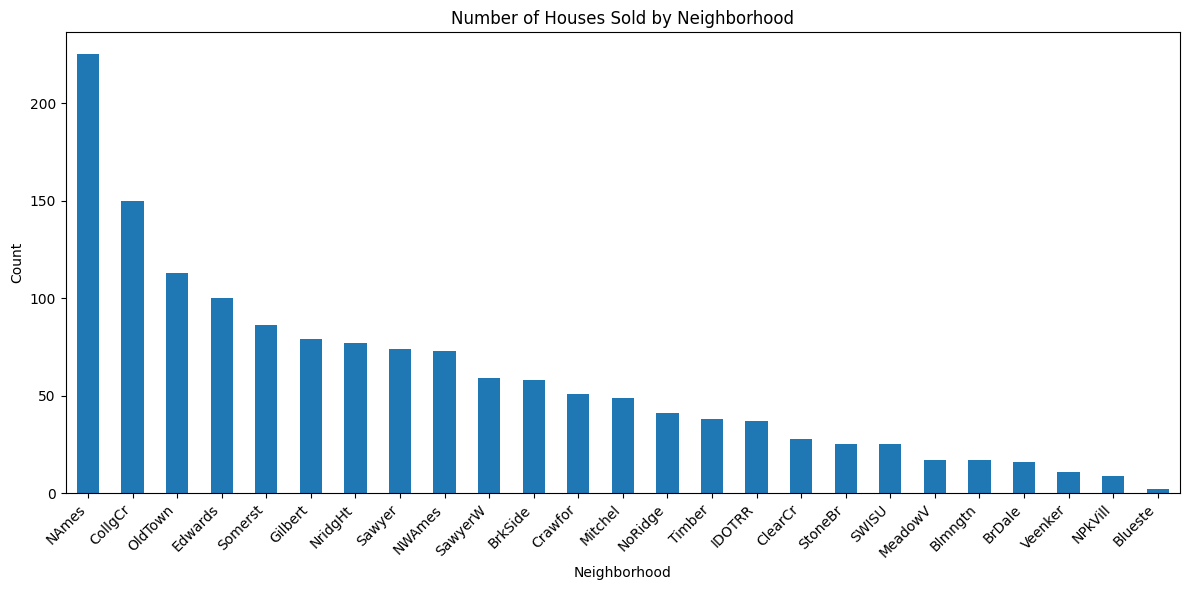

In [13]:
plt.figure(figsize=(12, 6))
df["Neighborhood"].value_counts().plot(kind="bar")
plt.title("Number of Houses Sold by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Finding:** `NAmes` is by far the most common neighborhood, about 150% ahead of the runner-up. Several neighborhoods are sparse: `MeadowV` and `Blmngtn` (17 each), `BrDale` (16), `Veenker` (11), `NPkVill` (9), and `Blueste` at just 2. Any conclusion tied specifically to `Blueste` should be treated with caution given the sample size.

**Flagged for bivariate:** does `NAmes`, as the most common neighborhood, sell near the overall median `SalePrice`?

## LotArea

The last column from the original hypothesis. Prediction: right-skewed, same as other area measurements. Note: `LotArea` did not look like a strong price proxy among the outlier houses checked earlier, which is worth revisiting here.

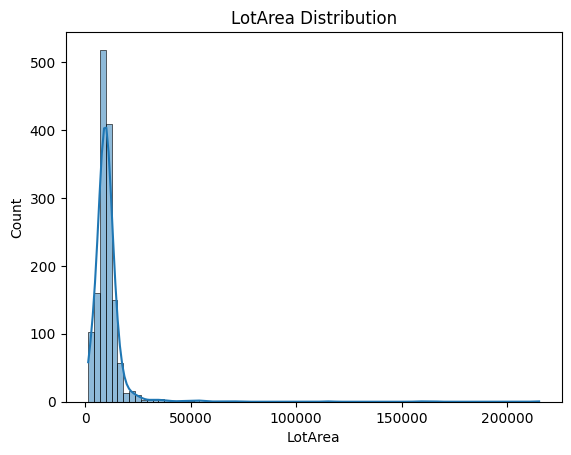

np.float64(12.207687851233496)

In [14]:
sns.histplot(data=df, x="LotArea", kde=True)
plt.title("LotArea Distribution")
plt.show()

df["LotArea"].skew()

In [15]:
df["LotArea"].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

In [16]:
find_outliers(df, "LotArea")

Bounds: 1482 to 17674. Outliers: 69


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
313,314,20,RL,150.0,215245,Pave,None,IR3,Low,AllPub,...,0,None,None,None,0,6,2009,WD,Normal,375000
335,336,190,RL,85.0,164660,Grvl,None,IR1,HLS,AllPub,...,0,None,None,Shed,700,8,2008,WD,Normal,228950
249,250,50,RL,80.0,159000,Pave,None,IR2,Low,AllPub,...,0,None,None,Shed,500,6,2007,WD,Normal,277000
706,707,20,RL,80.0,115149,Pave,None,IR2,Low,AllPub,...,0,None,None,None,0,6,2007,WD,Normal,302000
451,452,20,RL,62.0,70761,Pave,None,IR1,Low,AllPub,...,0,None,None,None,0,12,2006,WD,Normal,280000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854,855,20,RL,102.0,17920,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,7,2006,WD,Abnorml,170000
1277,1278,80,RL,80.0,17871,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,6,2009,WD,Normal,197900
1151,1152,20,RL,134.0,17755,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,11,2006,WD,Normal,149900
1039,1040,180,RM,21.0,1477,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2009,WD,Normal,80000


**Finding:** skew of 12.2, the most extreme of the week. Median is 9,478, max is 215,245, over 22 times the median. The 25th and 75th percentiles sit close together (7,553 to 11,601), consistent with lot sizes within an area usually being similar, with a small number of much larger exceptions. IQR check found 69 outliers, all above the upper bound.

Checked the single highest outlier (215,245 sq ft) against `SalePrice`, `Neighborhood`, `GrLivArea`, and `OverallQual`: it is also a price outlier, has an unremarkable `GrLivArea`, and a quality rating of 7. Looking at the row directly, it is an old, irregularly shaped, single-storey house with no fence, a profile consistent with a genuinely large older-style lot rather than a data error. This only verifies the single top outlier, not all 69.

# Bivariate and Multivariate Analysis

Testing the hypotheses flagged during univariate analysis:
- Does `NAmes` sell near the overall median `SalePrice`?
- Do `OverallQual` and `GrLivArea` actually correlate with `SalePrice`?
- Is `LotArea` really a weak proxy, as it appeared among the outliers?
- Do `NoRidge` and `NridgHt` have the highest average prices overall, or were they just overrepresented among outliers?

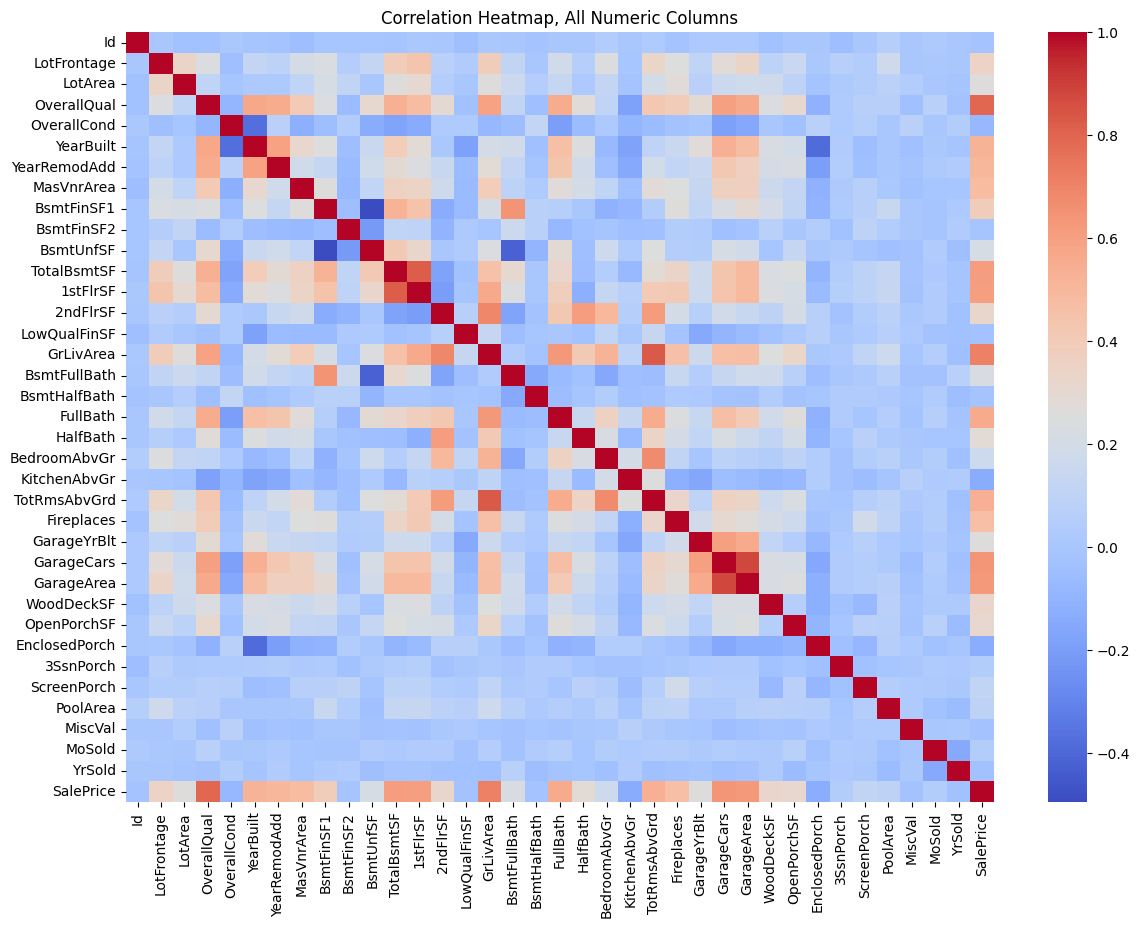

In [17]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap, All Numeric Columns")
plt.show()

## Correlation Against SalePrice

In [18]:
cols_to_check = ["OverallQual", "GrLivArea", "LotArea", "TotalBsmtSF", "YearBuilt", "GarageArea", "TotRmsAbvGrd", "SalePrice"]
df[cols_to_check].corr()["SalePrice"].sort_values(ascending=False)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageArea      0.623431
TotalBsmtSF     0.613581
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
LotArea         0.263843
Name: SalePrice, dtype: float64

**Verdict on the original hypothesis:**

- **Living area confirmed strong.** `GrLivArea` correlates at 0.71, second only to `OverallQual`.
- **Room count moderate.** `TotRmsAbvGrd` at 0.53, a real but weaker relationship, roughly tied with `YearBuilt`, which was not part of the original hypothesis.
- **Land area not supported.** `LotArea` at 0.26 is the weakest of the group, confirming the pattern from the outlier review across the full dataset.
- **Strongest predictor overall is `OverallQual`** at 0.79, not part of the original hypothesis at all.

Location still needs a separate test, since `Neighborhood` is categorical.

## Neighborhood: Price by Location

In [19]:
df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

**Finding:** `NoRidge` and `NridgHt` are genuinely the highest-priced neighborhoods overall, not just an artifact of the outlier group. `NAmes` sits below center, not exactly at the median.

**New hypothesis:** `NAmes` sells more because it is more affordable, likely due to older housing stock (predicted) and average, not above-average, quality (predicted around 7).

In [20]:
df[df["Neighborhood"] == "NAmes"][["YearBuilt", "OverallQual"]].describe()

,YearBuilt,OverallQual
count,225.000000,225.000000
mean,1959.995556,5.360000
std,8.770638,0.823321
min,1918.000000,3.000000
25%,1955.000000,5.000000
50%,1960.000000,5.000000
75%,1965.000000,6.000000
max,1998.000000,8.000000


**Finding:** `YearBuilt` confirmed, median 1960, tight spread (1955 to 1965). `OverallQual` was off: median is 5, not the predicted 7. `NAmes` looks affordable because it is genuinely older housing stock with average finishes, not a value neighborhood in the bargain sense.

## Does YearBuilt Correlate With OverallQual?

Checking whether the age and quality relationship found in `NAmes` holds across the whole dataset.

In [21]:
df["YearBuilt"].corr(df["OverallQual"])

np.float64(0.572322768962362)

**Finding:** 0.57, a genuine moderate correlation across the full dataset, not just `NAmes`. Testing whether `Neighborhood`, already shown to vary in both age and price, is acting as a confounder.

In [22]:
df.groupby("Neighborhood").apply(lambda x: x["YearBuilt"].corr(x["OverallQual"]))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Neighborhood
Blmngtn   -0.343897
Blueste         NaN
BrDale     0.430644
BrkSide   -0.429656
ClearCr    0.256139
CollgCr    0.693755
Crawfor    0.312907
Edwards    0.473619
Gilbert    0.481350
IDOTRR     0.021337
MeadowV    0.610838
Mitchel    0.466844
NAmes      0.163436
NPkVill         NaN
NWAmes     0.386981
NoRidge    0.245941
NridgHt    0.261178
OldTown   -0.211282
SWISU      0.246306
Sawyer     0.174412
SawyerW    0.482771
Somerst    0.244616
StoneBr    0.501597
Timber     0.695601
Veenker    0.637859
dtype: float64

**Finding:** the correlation varies widely by neighborhood, from -0.43 (`BrkSide`) to 0.70 (`Timber`), with `NAmes` itself dropping to 0.16. `Blueste` and `NPkVill` return NaN, both too small (2 and 9 houses) for a meaningful correlation.

**Verdict: `Neighborhood` is not a clean confounder here.** A true confounder shrinks a relationship toward zero everywhere once controlled for, since the entire apparent relationship was borrowed from it. Several neighborhoods here show a stronger correlation than the overall 0.57, not weaker, which means `YearBuilt` and `OverallQual` have a real, direct relationship. `Neighborhood` appears to interact with the strength of that relationship without explaining it away.

## GarageArea, TotalBsmtSF, TotRmsAbvGrd

These three already showed moderate to strong correlation with `SalePrice` above (0.62, 0.61, 0.53). A quick check before moving on.

In [23]:
df[["GarageArea", "TotalBsmtSF", "TotRmsAbvGrd"]].describe()

,GarageArea,TotalBsmtSF,TotRmsAbvGrd
count,1460.000000,1460.000000,1460.000000
mean,472.980137,1057.429452,6.517808
std,213.804841,438.705324,1.625393
min,0.000000,0.000000,2.000000
25%,334.500000,795.750000,5.000000
50%,480.000000,991.500000,6.000000
75%,576.000000,1298.250000,7.000000
max,1418.000000,6110.000000,14.000000


No further investigation here. These are secondary columns without a specific hypothesis or surprising pattern worth chasing, unlike `OverallQual`, `YearBuilt`, and `Neighborhood`.

## MoSold vs SalePrice

In [24]:
monthly = df.groupby("MoSold")["SalePrice"].agg(["mean", "count"]).sort_index()
monthly

,mean,count
MoSold,,
1,183256.258621,58
2,177882.000000,52
3,183253.924528,106
4,171503.262411,141
5,172307.269608,204
6,177395.735178,253
7,186331.192308,234
8,184651.827869,122
9,195683.206349,63


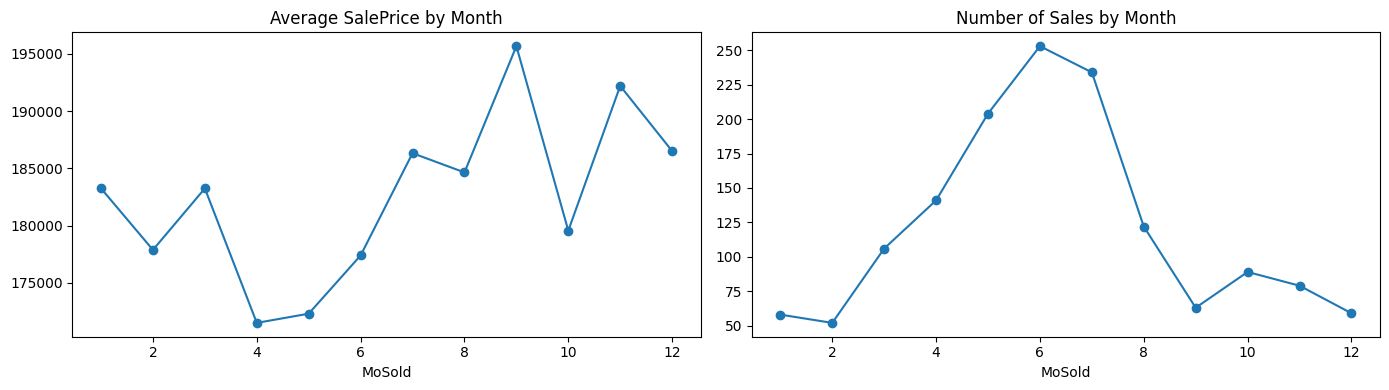

np.float64(-0.4128464048575746)

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly["mean"].plot(kind="line", marker="o", ax=axes[0], title="Average SalePrice by Month")
monthly["count"].plot(kind="line", marker="o", ax=axes[1], title="Number of Sales by Month")
plt.tight_layout()
plt.show()

monthly["mean"].corr(monthly["count"])

**Finding:** -0.41, a moderate negative correlation between sales volume and average price by month. Based on only 12 points, so more fragile than the row-level correlations elsewhere. Checking whether house characteristics differ by month, since that could explain the pattern without any seasonal effect on price itself.

In [26]:
df.groupby("MoSold")[["OverallQual", "GrLivArea"]].mean().sort_index()

,OverallQual,GrLivArea
MoSold,,
1,5.862069,1535.327586
2,6.269231,1460.711538
3,6.122642,1535.245283
4,6.042553,1456.673759
5,5.906863,1443.421569
6,6.019763,1501.225296
7,6.085470,1543.401709
8,6.131148,1562.385246
9,6.460317,1640.047619


**Finding:** September, the highest-priced month, also has the highest average `OverallQual` and `GrLivArea`. The price pattern is not seasonal: September's houses are simply bigger and higher quality on average. Month correlates with price only because it is a proxy for what kind of house tends to sell in a given month.

**Conclusion:** `MoSold` shows real statistical patterns with `SalePrice`, but is not a meaningful direct predictor on its own. Price is explained by house quality and size, already confirmed as the strongest drivers in this dataset. Sales volume by month (May to July peak) is best explained by real-world seasonal behavior, weather and the school calendar, rather than anything in the data itself.

## Why Is LotArea a Weak Predictor?

Testing two theories before accepting the weakness as unexplained.

**Theory 1:** does `LotArea` correlate more strongly within individual neighborhoods than across the whole dataset?

In [27]:
neighborhood_counts = df["Neighborhood"].value_counts()
reliable_neighborhoods = neighborhood_counts[neighborhood_counts >= 10].index

lot_area_corr = (
    df[df["Neighborhood"].isin(reliable_neighborhoods)]
    .groupby("Neighborhood")
    .apply(lambda x: x["LotArea"].corr(x["SalePrice"]))
)
lot_area_corr.sort_values(ascending=False)

Neighborhood
MeadowV    0.860518
Somerst    0.708892
NridgHt    0.700336
StoneBr    0.700292
Veenker    0.697285
BrkSide    0.639110
OldTown    0.615990
ClearCr    0.573157
SawyerW    0.538432
NAmes      0.477291
SWISU      0.406711
Blmngtn    0.378529
NoRidge    0.378220
CollgCr    0.377198
BrDale     0.363236
Sawyer     0.322230
NWAmes     0.258061
Edwards    0.239335
Timber     0.223482
Crawfor    0.201784
Gilbert    0.157257
IDOTRR     0.130044
Mitchel   -0.059413
dtype: float64

Filtered out neighborhoods with fewer than 10 houses. Any 2-point group produces a mathematically meaningless ±1.0 correlation, since two points always lie on a straight line. Results were mixed, not a clean confirmation either way.

**Theory 2:** does a neighborhood's lot-size consistency predict how strongly `LotArea` correlates with price there? Hypothesis: more uniform lot sizes should mean a stronger relationship, since any variation is more meaningful relative to the norm.

In [28]:
grouped = df.groupby("Neighborhood")["LotArea"]
cv = (grouped.std() / grouped.mean()) * 100

comparison = pd.DataFrame({
    "CV_LotArea": cv,
    "Corr_LotArea_SalePrice": lot_area_corr
}).dropna()

comparison["CV_LotArea"].corr(comparison["Corr_LotArea_SalePrice"])

np.float64(0.010633496547245068)

**Finding:** 0.01, essentially no relationship. The hypothesis was reasonable but not supported by the data.

**Conclusion:** two theories tested, neither explains `LotArea`'s weakness. Left as an honestly unexplained finding rather than forcing a conclusion the data does not support.

## Multivariate: Pairplot

A correlation heatmap gives a single number per pair, assuming a linear relationship. A pairplot shows the actual shape, which can reveal patterns a single number would hide or misrepresent.

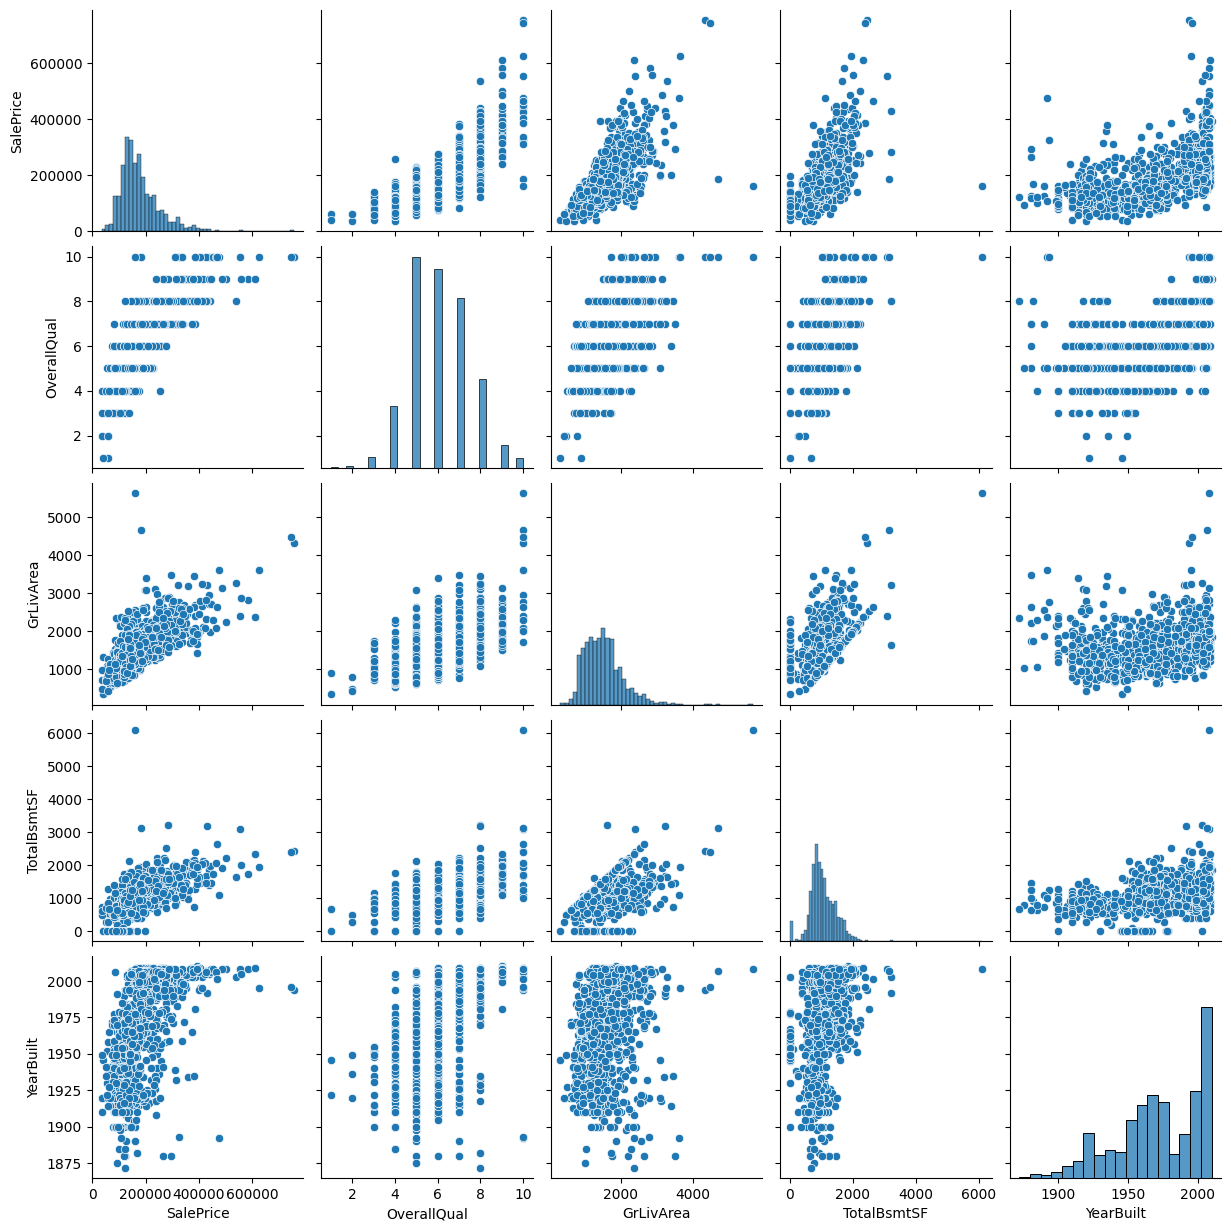

In [29]:
cols_for_pairplot = ["SalePrice", "OverallQual", "GrLivArea", "TotalBsmtSF", "YearBuilt"]
sns.pairplot(df[cols_for_pairplot])
plt.show()

**Observation:** a faint diagonal pattern is visible between `GrLivArea` and `TotalBsmtSF`, amid a lot of scatter, suggesting a possible weak relationship. Noted, not formally tested.

## Summary of Key Findings

**Confirmed:**
1. `GrLivArea` is a strong predictor of `SalePrice` (r = 0.71), matching the original hypothesis.
2. `NoRidge` and `NridgHt` are genuinely the highest-priced neighborhoods, not just overrepresented among outliers.

**Overturned or revised:**
3. `LotArea` was the weakest numeric predictor (r = 0.26), the opposite of the original guess. Two follow-up theories were tested and ruled out; the weakness remains unexplained.
4. `NAmes` was assumed to be an affordable value neighborhood. It is actually old housing stock with average, not above-average, quality.

**New findings:**
5. `OverallQual` is the single strongest predictor (r = 0.79), not part of the original plan, and structurally different from most columns since it is a bounded 1 to 10 scale rather than an open-ended measurement.
6. `YearBuilt` correlates moderately with `OverallQual` (r = 0.57). `Neighborhood` was tested as a possible confounder and ruled out: the relationship persists, and even strengthens, within individual neighborhoods.
7. `MoSold`'s apparent price pattern is fully explained by house size and quality differences by month, not a seasonal price effect. The separate volume pattern reflects real-world seasonal behavior outside what the data can explain.
8. Houses with no fence had a higher average `SalePrice` than any fenced category, only partially explained by slightly larger average lot sizes.

**Open threads:**
- `LotArea`'s weak correlation remains unexplained despite two tested theories.
- The faint `GrLivArea` and `TotalBsmtSF` pairplot pattern was noted but not formally tested.

**Limitations:**
- `Blueste` (2 houses) and `NPkVill` (9 houses) are too sparse for reliable neighborhood-level conclusions.
- Month-level correlations (for example, the -0.41 volume and price relationship) are based on only 12 points and are more fragile than the dataset's row-level correlations.

## Next Steps

EDA phase complete. Next: predictive modeling, building on `OverallQual`, `GrLivArea`, and `Neighborhood` as the strongest candidate features.